# Text Classification Using BERT & Tensorflow


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [2]:
import tensorflow as tf
import numpy as np
import tensorflow_hub as hub
import tensorflow_text as text  # Required to run exported models with text input

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("TensorFlow Hub version:", hub.__version__)
print("TensorFlow Text version:", text.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.0.2
TensorFlow Hub version: 0.16.1
TensorFlow Text version: 2.20.1


In [3]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/MottuqeBrid/TensorFlow/refs/heads/main/15%20Text%20Classification%20Using%20BERT%20%26%20Tensorflow/spam.csv")
df.head(5)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.groupby("Category").describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [5]:
df["Category"].value_counts()

,count
Category,
ham,4825
spam,747


In [6]:
df_spam = df[df["Category"]=="spam"]
df_spam.shape

(747, 2)

In [7]:
df_ham = df[df["Category"]=="ham"]
df_ham.shape

(4825, 2)

In [8]:
df_ham_downsample = df_ham.sample(df_spam.shape[0])
df_ham_downsample.shape

(747, 2)

In [9]:
df_balanced = pd.concat([df_spam, df_ham_downsample])
df_balanced.shape

(1494, 2)

In [10]:
df_balanced["Category"].value_counts()

,count
Category,
spam,747
ham,747


In [11]:
df_balanced.sample(5)

,Category,Message
3063,ham,Fine. Do you remember me.
5326,ham,What makes you most happy?
1767,spam,SMS AUCTION You have won a Nokia 7250i. This i...
1172,spam,Got what it takes 2 take part in the WRC Rally...
2207,spam,"URGENT! Your mobile No 07xxxxxxxxx won a £2,00..."


In [12]:
df_balanced["spam"]= df_balanced["Category"].apply(lambda x: 1 if x == "spam" else 0)
df_balanced.sample(10)

,Category,Message,spam
1072,spam,URGENT! We are trying to contact U. Todays dra...,1
2272,ham,Life spend with someone for a lifetime may be ...,0
3649,ham,As per your request 'Maangalyam (Alaipayuthe)'...,0
660,spam,88800 and 89034 are premium phone services cal...,1
5314,spam,Get the official ENGLAND poly ringtone or colo...,1
5172,ham,"Aight, text me tonight and we'll see what's up",0
2074,spam,FreeMsg: Claim ur 250 SMS messages-Text OK to ...,1
4499,spam,Latest Nokia Mobile or iPOD MP3 Player +£400 p...,1
5426,ham,Oh yeah! And my diet just flew out the window,0
2642,spam,"You are guaranteed the latest Nokia Phone, a 4...",1


In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df_balanced['Message'], df_balanced['spam'], stratify=df_balanced["spam"], random_state=1)

In [14]:
x_train.head()

,Message
5172,"Aight, text me tonight and we'll see what's up"
2850,YOUR CHANCE TO BE ON A REALITY FANTASY SHOW ca...
3322,Yo im right by yo work
2742,I don't know u and u don't know me. Send CHAT ...
3786,Let me know if you need anything else. Salad o...


In [15]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4")

In [16]:
def get_sentence_embeding(sentences):
  preprocessed_text = bert_preprocess(sentences)
  return bert_encoder(preprocessed_text)["pooled_output"]
get_sentence_embeding([
    "500$ discount. hurry up",
    "Bhavin, are you up for a volleybal game tomorrow?"]
)

<tf.Tensor: shape=(2, 768), dtype=float32, numpy=
array([[-0.84351695, -0.5132726 , -0.8884571 , ..., -0.7474885 ,
        -0.7531473 ,  0.91964495],
       [-0.8720836 , -0.50543964, -0.9444667 , ..., -0.858475  ,
        -0.7174534 ,  0.8808298 ]], dtype=float32)>

In [17]:
e = get_sentence_embeding([
    "banana",
    "grapes",
    "mango",
    "jeff bezos",
    "elon musk",
    "bill gates"
]
)

In [18]:
from sklearn.metrics.pairwise import  cosine_similarity

cosine_similarity([e[0]],[e[1]])

array([[0.9911087]], dtype=float32)

In [19]:
cosine_similarity([e[4]],[e[5]])

array([[0.9164159]], dtype=float32)

In [20]:
# Bart Layers
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)

# Neural network layears
l = tf.keras.layers.Dropout(0.1, name="dropout")(outputs["pooled_output"])
l = tf.keras.layers.Dense(1, activation="sigmoid", name="output")(l)

# Construct final model
# model = tf.keras.Model(input=[text_input], output=[l])
model = tf.keras.Model(inputs=[text_input], outputs=[l])

In [21]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

In [22]:
METRICS = [
      tf.keras.metrics.BinaryAccuracy(name='accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall')
]

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=METRICS)

In [23]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
35/35 [==============================] - 367s 10s/step - loss: 0.6266 - accuracy: 0.6643 - precision: 0.6840 - recall: 0.6107
Epoch 2/5
35/35 [==============================] - 356s 10s/step - loss: 0.5212 - accuracy: 0.7857 - precision: 0.7857 - recall: 0.7857
Epoch 3/5
35/35 [==============================] - 358s 10s/step - loss: 0.4522 - accuracy: 0.8330 - precision: 0.8221 - recall: 0.8500
Epoch 4/5
35/35 [==============================] - 359s 10s/step - loss: 0.3979 - accuracy: 0.8848 - precision: 0.8634 - recall: 0.9143
Epoch 5/5
35/35 [==============================] - 360s 10s/step - loss: 0.3688 - accuracy: 0.8902 - precision: 0.8813 - recall: 0.9018


In [24]:
model.evaluate(x_test, y_test)

12/12 [==============================] - 125s 10s/step - loss: 0.3261 - accuracy: 0.9064 - precision: 0.8838 - recall: 0.9358


[0.3261059820652008,
 0.9064171314239502,
 0.8838383555412292,
 0.9358288645744324]

In [25]:
y_predict = model.predict(x_test)
y_predict = y_predict.flatten()

12/12 [==============================] - 143s 12s/step


In [26]:
import numpy as np

y_predict = np.where(y_predict > 0.5, 1, 0)
y_predict

array([1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predict)
cm

array([[164,  23],
       [ 12, 175]])

Text(50.722222222222214, 0.5, 'Truth')

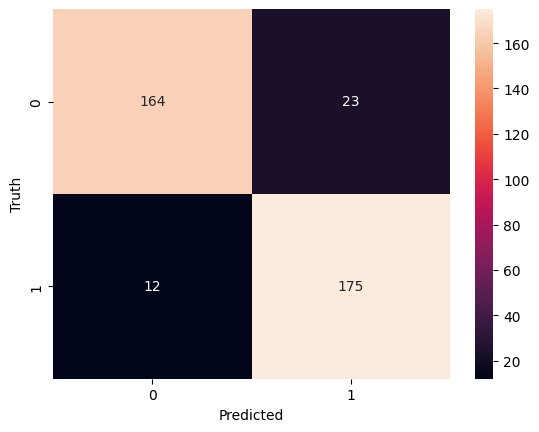

In [28]:
import matplotlib.pyplot as plt
import seaborn as sn

sn.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [29]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90       187
           1       0.88      0.94      0.91       187

    accuracy                           0.91       374
   macro avg       0.91      0.91      0.91       374
weighted avg       0.91      0.91      0.91       374



# Inference

In [30]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 3s 3s/step


array([[0.65289927],
       [0.76185465],
       [0.7427981 ],
       [0.27973303],
       [0.20430875]], dtype=float32)